In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/HAM10000_metadata.csv")
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


In [4]:
df["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

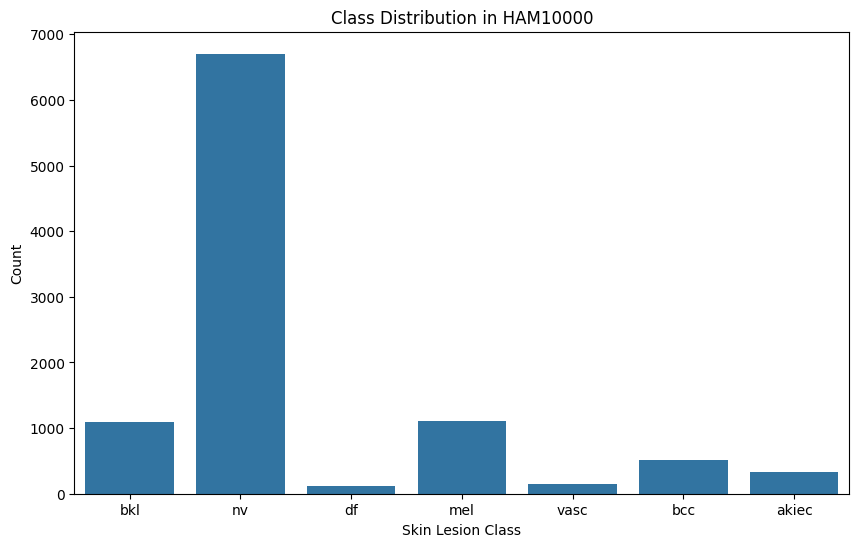

In [5]:
plt.figure(figsize=(10,6))
sns.countplot(x="dx", data=df)
plt.title("Class Distribution in HAM10000")
plt.xlabel("Skin Lesion Class")
plt.ylabel("Count")
plt.show()

In [6]:
plt.savefig("../outputs/figures/class_distribution.png")


<Figure size 640x480 with 0 Axes>

In [7]:
# Lesion Image Visualization

In [ ]:
#Import Image Libraries
from PIL import Image
import os

In [17]:
#Create Image Path Mapping
image_dir_1 = "../data/raw/HAM10000_images_part_1"
image_dir_2 = "../data/raw/HAM10000_images_part_2"

image_paths = {}

for folder in [image_dir_1, image_dir_2]:
    for img in os.listdir(folder):
        image_id = img.split(".")[0]
        image_paths[image_id] = os.path.join(folder, img)
        

In [18]:
#Add Image Path Column
df["image_path"] = df["image_id"].map(image_paths)

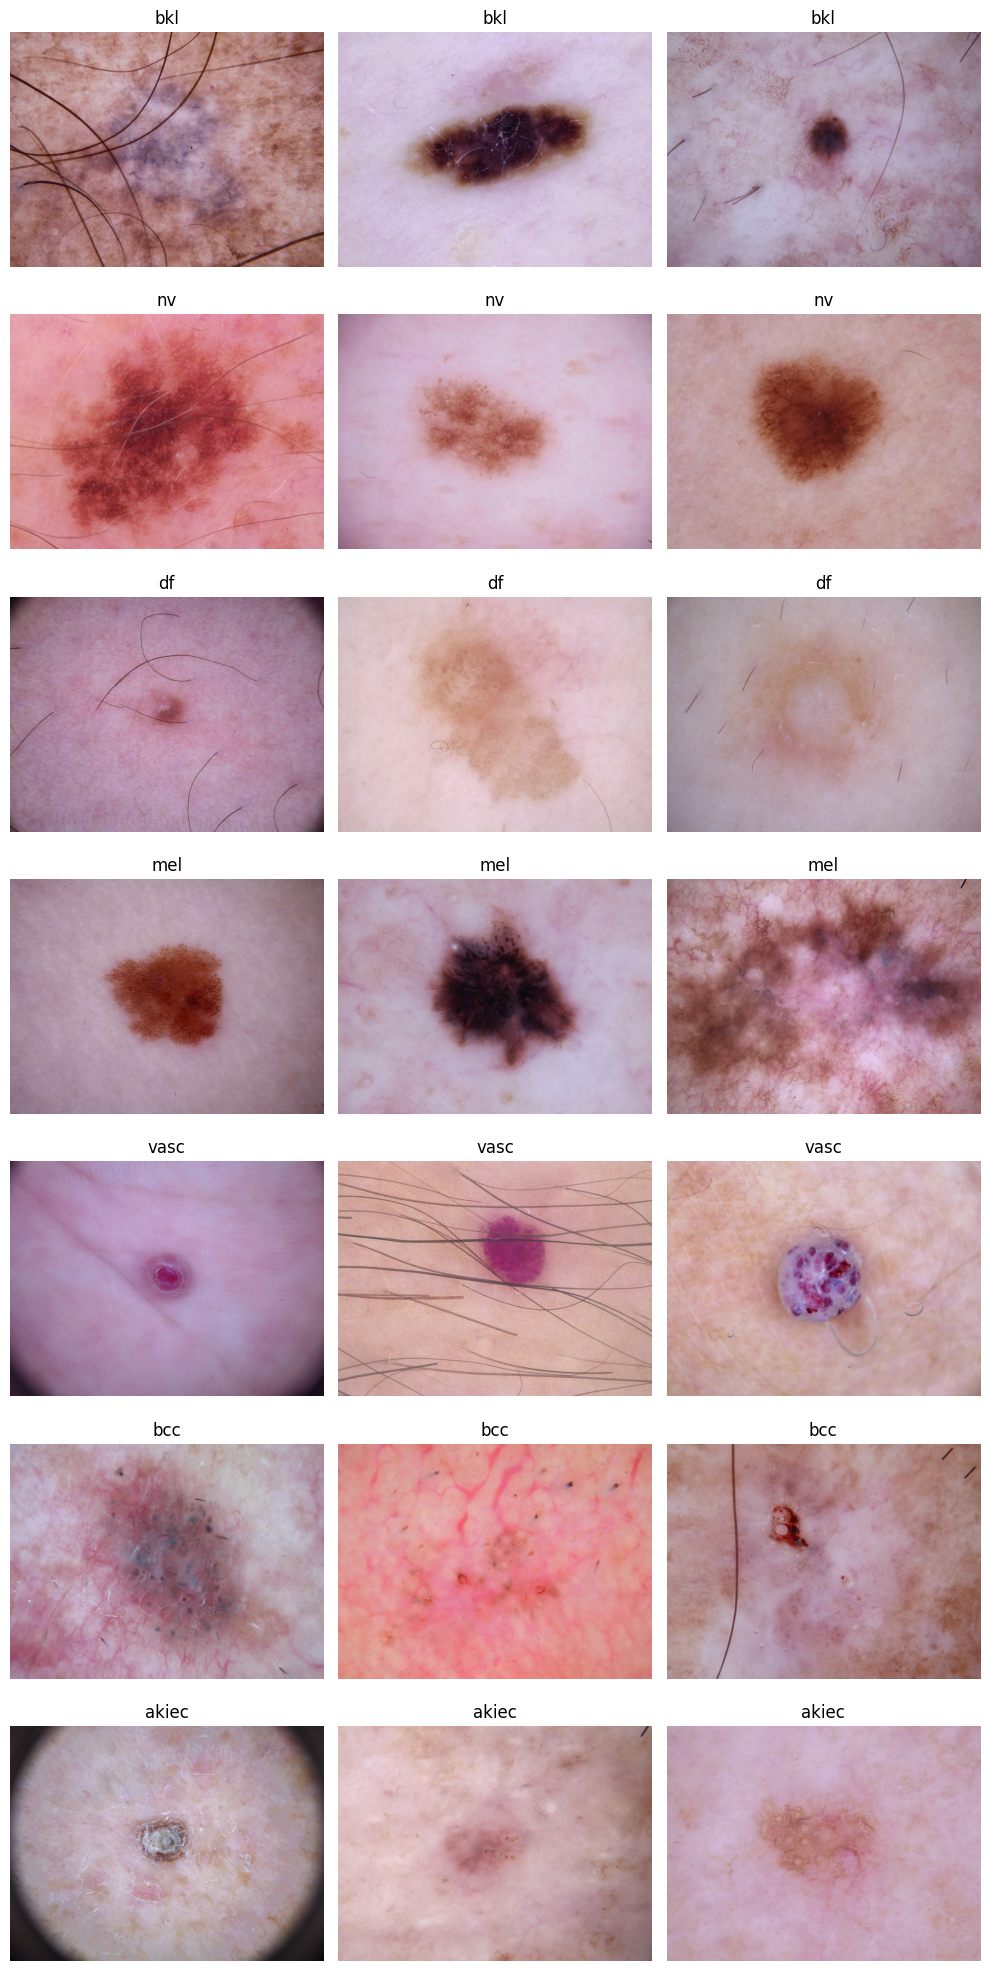

In [19]:
#Display Sample Images
classes = df["dx"].unique()

fig, axes = plt.subplots(len(classes), 3, figsize=(10, 20))

for i, lesion_class in enumerate(classes):
    samples = df[df["dx"] == lesion_class].sample(3)

    for j, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row["image_path"])

        axes[i, j].imshow(img)
        axes[i, j].set_title(lesion_class)
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

In [12]:
# Data Preprocessing and Dataset Split

In [20]:
#Encode Labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["dx"])

df[["dx", "label"]].head()

,dx,label
0,bkl,2
1,bkl,2
2,bkl,2
3,bkl,2
4,bkl,2


In [21]:
#Train/Validation/Test Split
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

In [ ]:
#Verify Split Sizes
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 7010
Validation size: 1502
Test size: 1503


In [22]:
#Verify Stratification
print(train_df["dx"].value_counts(normalize=True))
print(val_df["dx"].value_counts(normalize=True))
print(test_df["dx"].value_counts(normalize=True))

dx
nv       0.669472
mel      0.111127
bkl      0.109700
bcc      0.051355
akiec    0.032668
vasc     0.014123
df       0.011555
Name: proportion, dtype: float64
dx
nv       0.669774
mel      0.111185
bkl      0.109854
bcc      0.051265
akiec    0.032623
vasc     0.013981
df       0.011318
Name: proportion, dtype: float64
dx
nv       0.669328
mel      0.111111
bkl      0.109780
bcc      0.051231
akiec    0.032601
vasc     0.014637
df       0.011311
Name: proportion, dtype: float64


In [23]:
# Image Preprocessing Pipeline

In [24]:
#Import TorchVision Transforms
from torchvision import transforms


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/owner/lightweight-vit-skin-cancer-classification/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/owner/lightweight-vit-skin-cancer-classification/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/Users/owner/lightweight-vit-skin-cancer-classification/.venv/

In [25]:
#Define Image Size
IMG_SIZE = 224

In [27]:
#Training Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [28]:
#Validation/Test Transforms

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])